## Medicine Supply Chain Disruption Predictor

### What are we predicting?
- Target: Will a specfic medicine face a shortage? (Yes/No)

### What does one row represent?
- One medicine, in one month

### What columns do we need?
- Drug name, production volume, import quantity, shortage history

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("pandas version:", pd.__version__)
print("numpy version:", np.__version__)
print("All libraries loaded sucessfully!")

pandas version: 3.0.1
numpy version: 2.4.3
All libraries loaded sucessfully!


In [2]:
import requests
import os

In [3]:
os.makedirs('data', exist_ok=True)

In [5]:
url = "https://data.gov.in/sites/default/files/datafile/Drug_licences.csv"

response = requests.get(url)

if response.status_code == 200:
    with open('data/drug_licences.csv', 'wb') as f:
        f.write(response.content)
    print("Download successfully!")
else:
    print("Status code:", response.status_code)
    print("we will try another source")        

Status code: 504
we will try another source


In [7]:
from bs4 import BeautifulSoup

os.makedirs('data', exist_ok=True)

url ="https://cdsco.gov.in/opencms/opencms/en/consumer/Not-of-Standard-Quality/"

headers = { 
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}

response = requests.get(url, headers=headers, timeout=30)
print('Status code:', response.status_code)
print("Page size:", len(response.text), "characters")

Status code: 404
Page size: 7145 characters


In [8]:
os.makedirs('data', exist_ok=True)

url = "https://cdsco.gov.in/opencms/opencms/en/drugs/Drug-Alerts/"

headers = { 
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}

response = requests.get(url, headers=headers, timeout=30)
print('Status code:', response.status_code)
print("Page size:", len(response.text), "characters")

if response.status_code == 200:
    soup = BeautifulSoup(response.text, "html.parser")

    tables = soup.find_all('table')
    print("Number of tables found:", len(tables))

Status code: 404
Page size: 7115 characters


In [9]:
os.makedirs('data', exist_ok=True)

url = "https://api.fda.gov/drug/shortage.json?limit=100"

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}

response = requests.get(url, headers=headers, timeout=30)
print('status code:', response.status_code)

if response.status_code ==200:
    data = response.json()
    print("Total records available:", data['meta']['results']['total'])
    print("Records downloaded:", len(data['results']))
    print("\nFirst record sample:")
    print(data['results'][0])



status code: 404


In [10]:
os.makedirs('data', exist_ok=True)

url = "https://raw.githubusercontent.com/datasets/pharmaceutical-drug-spending/master/data/drug-spending.csv"

response = requests.get(url, timeout=30)
print("Status code:", response.status_code)

if response.status_code == 200:
    # Read directly into pandas without saving first
    from io import StringIO
    df = pd.read_csv(StringIO(response.text))
    print("Shape:", df.shape)
    print("\nColumns:", df.columns.tolist())
    print("\nFirst 5 rows:")
    print(df.head())

Status code: 404


In [11]:
from io import StringIO

url = "https://raw.githubusercontent.com/plotly/datasets/master/pharmaceutical_sales.csv"

response = requests.get(url, timeout=30)
print("Status code:", response.status_code)

if response.status_code == 200:
    df = pd.read_csv(StringIO(response.text))
    print("Shape:", df.shape)
    print("\nColumns:", df.columns.tolist())
    print("\nFirst 5 rows:")
    print(df.head())
else:
    print("Failed:", response.status_code)


Status code: 404
Failed: 404


In [12]:
import json

with open('data/drug-shortages-0001-of-0001.json', 'r') as f:
    raw_data = json.load(f)
print("Keys in file:", raw_data.keys())
print("Total records:", len(raw_data['results']))
print("\nFirst record:")
print(raw_data['results'][0])

Keys in file: dict_keys(['meta', 'results'])
Total records: 1703

First record:
{'update_type': 'Revised', 'initial_posting_date': '04/02/2020', 'package_ndc': '23155-601-41', 'generic_name': 'Midazolam Hydrochloride Injection', 'contact_info': '855-228-9470', 'availability': 'Unavailable', 'related_info': 'Estimated availability: 5/25/2026', 'openfda': {'application_number': ['ANDA090850'], 'brand_name': ['MIDAZOLAM HYDROCHLORIDE'], 'generic_name': ['MIDAZOLAM HYDROCHLORIDE'], 'manufacturer_name': ['Heritage Pharmaceuticals Inc. d/b/a Avet Pharmaceuticals Inc.'], 'product_ndc': ['23155-601'], 'product_type': ['HUMAN PRESCRIPTION DRUG'], 'route': ['INTRAMUSCULAR', 'INTRAVENOUS'], 'substance_name': ['MIDAZOLAM HYDROCHLORIDE'], 'rxcui': ['311702'], 'spl_id': ['e20feff9-3aca-4bc1-a5c3-44fff8a9459c'], 'spl_set_id': ['843cc25e-45ea-4372-ae34-843f805fa869'], 'package_ndc': ['23155-601-31', '23155-601-41', '23155-601-32', '23155-601-42'], 'unii': ['W7TTW573JJ']}, 'update_date': '03/16/2026', 

In [13]:
df = pd.DataFrame(raw_data['results'])

print("Shape of the dataset:", df.shape)
print("\ncolumn names:")
print(df.columns.tolist())
print("\nFrist 5 rows:")
df.head()

Shape of the dataset: (1703, 19)

column names:
['update_type', 'initial_posting_date', 'package_ndc', 'generic_name', 'contact_info', 'availability', 'related_info', 'openfda', 'update_date', 'therapeutic_category', 'dosage_form', 'presentation', 'company_name', 'shortage_reason', 'status', 'discontinued_date', 'change_date', 'resolved_note', 'related_info_link']

Frist 5 rows:


,update_type,initial_posting_date,package_ndc,generic_name,contact_info,availability,related_info,openfda,update_date,therapeutic_category,dosage_form,presentation,company_name,shortage_reason,status,discontinued_date,change_date,resolved_note,related_info_link
0,Revised,04/02/2020,23155-601-41,Midazolam Hydrochloride Injection,855-228-9470,Unavailable,Estimated availability: 5/25/2026,"{'application_number': ['ANDA090850'], 'brand_...",03/16/2026,"[Anesthesia, Neurology]",Injection,"Midazolam Hydrochloride, Injection, 5 mg/1 mL ...","Avet Pharmaceuticals, Inc.",Demand increase for the drug,Current,NaN,NaN,NaN,NaN
1,Reverified,11/01/2023,60505-4744-1,Lisdexamfetamine Dimesylate Capsule,800-706-5575,Available,NaN,"{'application_number': ['ANDA216944'], 'brand_...",03/17/2026,[Psychiatry],Capsule,"Lisdexamfetamine Dimesylate, Capsule, 60 mg (N...",Apotex Corp.,NaN,Current,NaN,NaN,NaN,NaN
2,New,03/24/2026,55513-800-60,Ivabradine Hydrochloride Tablet,1-800-772-6436,NaN,Discontinuation of the manufacture of the drug...,"{'application_number': ['NDA206143'], 'brand_n...",03/24/2026,[Cardiovascular],Tablet,"Corlanor, Tablet, eq. 5 mg base (NDC 55513-800...",Amgen Inc.,NaN,To Be Discontinued,01/01/2026,NaN,NaN,NaN
3,Reverified,07/14/2023,64850-551-01,Lisdexamfetamine Dimesylate Capsule,888-852-6657,Limited Availability,Estimated recovery: TBD,"{'application_number': ['ANDA218604'], 'brand_...",03/17/2026,[Psychiatry],Capsule,"Lisdexamfetamine Dimesylate, Capsule, 20 mg (N...","Elite Laboratories, Inc.",Shortage of an active ingredient,Current,NaN,NaN,NaN,NaN
4,Reverified,07/14/2023,0054-0375-25,Lisdexamfetamine Dimesylate Capsule,800-631-2174,Limited Availability,Available on allocation,"{'application_number': ['ANDA202827'], 'brand_...",03/12/2026,[Psychiatry],Capsule,"Lisdexamfetamine Dimesylate, Capsule, 70 mg (N...","Hikma Pharmaceuticals USA, Inc.",Shortage of an active ingredient,Current,NaN,NaN,NaN,NaN


In [14]:
print("=== Missing Values ===")
display(df.isnull().sum())

print("=== Status Counts ===")
display(df['status'].value_counts())

print("=== Top Shortage Reason ===")
display(df['shortage_reason'].value_counts().head(10))

print("=== Availability Breakdown")
display(df['availability'].value_counts())

=== Missing Values ===


update_type                0
initial_posting_date       0
package_ndc                0
generic_name               0
contact_info               0
availability             560
related_info             571
openfda                  144
update_date                0
therapeutic_category       0
dosage_form               11
presentation               0
company_name               0
shortage_reason         1290
status                     0
discontinued_date       1185
change_date             1637
resolved_note           1662
related_info_link       1676
dtype: int64

=== Status Counts ===


status
Current               1143
To Be Discontinued     519
Resolved                41
Name: count, dtype: int64

=== Top Shortage Reason ===


shortage_reason
Other                                                                  152
Demand increase for the drug                                            98
Shortage of an active ingredient                                        78
Discontinuation of the manufacture of the drug                          37
Delay in shipping of the drug                                           24
Requirements related to complying with good manufacturing practices     21
Regulatory delay                                                         2
Shortage of an inactive ingredient component                             1
Name: count, dtype: int64

=== Availability Breakdown


availability
Available               741
Unavailable             281
Limited Availability    115
Limited Availablity       3
Information pending       2
Limited Availabiltiy      1
Name: count, dtype: int64

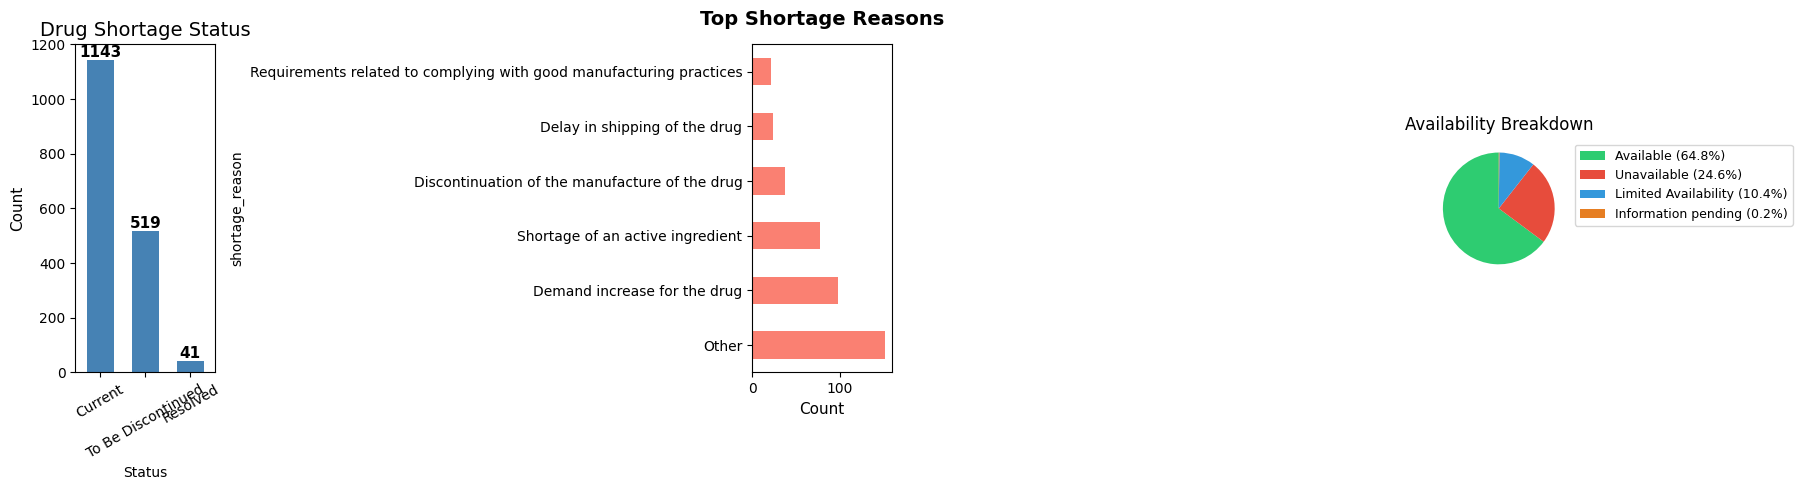

Charts Saved


In [15]:
fig, axes = plt.subplots(1,3,figsize=(18,5))

df['status'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue'], width=0.6)
axes[0].set_title('Drug Shortage Status', fontsize=14)
axes[0].set_xlabel('Status', fontsize=10)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(df['status'].value_counts()):
    axes[0].text(i,v + 10,str(v), ha='center', fontsize=11,fontweight='bold')
    

df['shortage_reason'].value_counts().head(6).plot(kind='barh',ax=axes[1], color='salmon')
axes[1].set_title('Top Shortage Reasons', fontsize=14, fontweight='bold', pad=14)
axes[1].set_xlabel('Count',fontsize=11)


df['availability'] = df['availability'].replace({
    'Limited Availablity': 'Limited Availability',
    'Limited Availabiltiy': 'Limited Availability'
})
top4 = df['availability'].value_counts().head(4)
colors = ['#2ecc71', '#e74c3c', '#3498db', '#e67e22']

total = top4.sum()
legend_labels = [f"{label} ({val/total*100:.1f}%)" 
                 for label, val in zip(top4.index, top4)]

axes[2].pie(top4, labels=None, autopct=None,
            colors=colors, startangle=90)
axes[2].set_title('Availability Breakdown')
axes[2].legend(labels=legend_labels, loc='upper left',
               bbox_to_anchor=(1, 1), fontsize=9)

plt.tight_layout()
plt.savefig('data/eda_charts.png', dpi=150,bbox_inches='tight')
plt.show()
print("Charts Saved")

In [16]:
for col in df.columns:
    try:
        print(f"{col}: {df[col].nunique()} unique values, {df[col].isnull().sum()} missing")
    except:
        print(f"{col}: contains nested data(dict/list) - will drop this column")    

update_type: 3 unique values, 0 missing
initial_posting_date: 197 unique values, 0 missing
package_ndc: 1682 unique values, 0 missing
generic_name: 241 unique values, 0 missing
contact_info: 155 unique values, 0 missing
availability: 4 unique values, 560 missing
related_info: 242 unique values, 571 missing
openfda: contains nested data(dict/list) - will drop this column
update_date: 129 unique values, 0 missing
therapeutic_category: contains nested data(dict/list) - will drop this column
dosage_form: 29 unique values, 11 missing
presentation: 1695 unique values, 0 missing
company_name: 129 unique values, 0 missing
shortage_reason: 8 unique values, 1290 missing
status: 3 unique values, 0 missing
discontinued_date: 108 unique values, 1185 missing
change_date: 9 unique values, 1637 missing
resolved_note: 1 unique values, 1662 missing
related_info_link: 15 unique values, 1676 missing


In [17]:
columns_to_keep =['generic_name','status', 'availability', 'shortage_reason', 'dosage_form','company_name','initial_posting_date', 'update_type']
df_clean = df[columns_to_keep].copy()

print("Original Shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("\nFirst 3 rows")
df_clean.head(3)

Original Shape: (1703, 19)
Cleaned shape: (1703, 8)

First 3 rows


,generic_name,status,availability,shortage_reason,dosage_form,company_name,initial_posting_date,update_type
0,Midazolam Hydrochloride Injection,Current,Unavailable,Demand increase for the drug,Injection,"Avet Pharmaceuticals, Inc.",04/02/2020,Revised
1,Lisdexamfetamine Dimesylate Capsule,Current,Available,NaN,Capsule,Apotex Corp.,11/01/2023,Reverified
2,Ivabradine Hydrochloride Tablet,To Be Discontinued,NaN,NaN,Tablet,Amgen Inc.,03/24/2026,New


In [18]:
df['therapeutic_category_clean']=df['therapeutic_category'].apply(lambda x:x[0] if isinstance(x,list) and len(x)>0 else 'Unknown')
print("Unique categories:")
print(df['therapeutic_category_clean'].value_counts())

Unique categories:
therapeutic_category_clean
Anesthesia                    341
Psychiatry                    248
Cardiovascular                211
Endocrinology/Metabolism      181
Analgesia/Addiction           171
Neurology                     114
Anti-Infective                 95
Oncology                       78
Rheumatology                   55
Gastroenterology               46
Hematology                     26
Dermatology                    23
Other                          21
Pulmonary/Allergy              21
Antiviral                      20
Renal                          13
Transplant                     11
Ophthalmology                   8
Urology                         7
Reproductive                    5
Total Parenteral Nutrition      3
Medical Imaging                 3
Pediatric                       2
Name: count, dtype: int64


In [19]:
df_clean['therapeutic_category']= df['therapeutic_category_clean']
print("Updated df_clean columns:")
print(df_clean.columns.tolist())
print("\nShape:", df_clean.shape)
print("\nMissing Values")
print(df_clean.isnull().sum())

Updated df_clean columns:
['generic_name', 'status', 'availability', 'shortage_reason', 'dosage_form', 'company_name', 'initial_posting_date', 'update_type', 'therapeutic_category']

Shape: (1703, 9)

Missing Values
generic_name               0
status                     0
availability             560
shortage_reason         1290
dosage_form               11
company_name               0
initial_posting_date       0
update_type                0
therapeutic_category       0
dtype: int64


In [20]:
df_clean['shortage_reason']=df_clean['shortage_reason'].fillna('Unknown')
df_clean['availability']=df_clean['availability'].fillna('Unknown')
df_clean['dosage_form']=df_clean['dosage_form'].fillna('Unknown')

df_clean['availability']=df_clean['availability'].replace({
    'Limited Availablity': 'Limited Availability', 'Limited Availabilitiy': 'Limited Availability'
})
print("Missing values after Fixing:")
print(df_clean.isnull().sum())

print("\nAvailability unique values:")
print(df_clean['availability'].value_counts())

Missing values after Fixing:
generic_name            0
status                  0
availability            0
shortage_reason         0
dosage_form             0
company_name            0
initial_posting_date    0
update_type             0
therapeutic_category    0
dtype: int64

Availability unique values:
availability
Available               741
Unknown                 560
Unavailable             281
Limited Availability    119
Information pending       2
Name: count, dtype: int64


In [22]:
df_clean['initial_posting_date'] = pd.to_datetime( df_clean['initial_posting_date'], format='%m/%d/%Y')

df_clean['year'] = df_clean['initial_posting_date'].dt.year
df_clean['month'] = df_clean['initial_posting_date'].dt.month

print('Date range of our data:')
print('Earliest shortage:', df_clean['initial_posting_date'].min())
print('Latest shortage:', df_clean['initial_posting_date'].max())
print('\nShortages by year:')
print(df_clean['year'].value_counts().sort_index())

Date range of our data:
Earliest shortage: 2012-01-01 00:00:00
Latest shortage: 2026-03-27 00:00:00

Shortages by year:
year
2012     78
2015      6
2016     24
2017    103
2018    164
2019     17
2020    150
2021     53
2022    174
2023    363
2024     38
2025    433
2026    100
Name: count, dtype: int64


In [23]:
df_clean.to_csv('data/df_clean.csv', index=False)

print("Clean Dataset saved!")
print("\nFinal dataset summary:")
print(f"Rows: {df_clean.shape[0]}")
print(f"Columns: {df_clean.shape[1]}")
print(f"\nColumns we have:")
for col in df_clean.columns:
    print(f" -{col}: {df_clean[col].nunique()} unique values")

Clean Dataset saved!

Final dataset summary:
Rows: 1703
Columns: 11

Columns we have:
 -generic_name: 241 unique values
 -status: 3 unique values
 -availability: 5 unique values
 -shortage_reason: 9 unique values
 -dosage_form: 30 unique values
 -company_name: 129 unique values
 -initial_posting_date: 197 unique values
 -update_type: 3 unique values
 -therapeutic_category: 23 unique values
 -year: 13 unique values
 -month: 12 unique values


In [24]:
#Loading Clean Dataset
df_clean = pd.read_csv("data/df_clean.csv")
print("Clean Data Loaded Successfully!")
print("shape:", df_clean.shape)
df_clean.head()

Clean Data Loaded Successfully!
shape: (1703, 11)


,generic_name,status,availability,shortage_reason,dosage_form,company_name,initial_posting_date,update_type,therapeutic_category,year,month
0,Midazolam Hydrochloride Injection,Current,Unavailable,Demand increase for the drug,Injection,"Avet Pharmaceuticals, Inc.",2020-04-02,Revised,Anesthesia,2020,4
1,Lisdexamfetamine Dimesylate Capsule,Current,Available,Unknown,Capsule,Apotex Corp.,2023-11-01,Reverified,Psychiatry,2023,11
2,Ivabradine Hydrochloride Tablet,To Be Discontinued,Unknown,Unknown,Tablet,Amgen Inc.,2026-03-24,New,Cardiovascular,2026,3
3,Lisdexamfetamine Dimesylate Capsule,Current,Limited Availability,Shortage of an active ingredient,Capsule,"Elite Laboratories, Inc.",2023-07-14,Reverified,Psychiatry,2023,7
4,Lisdexamfetamine Dimesylate Capsule,Current,Limited Availability,Shortage of an active ingredient,Capsule,"Hikma Pharmaceuticals USA, Inc.",2023-07-14,Reverified,Psychiatry,2023,7
